In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from win_prob import *
import numpy as np


In [6]:
df = pd.read_csv("Wimbledon_featured_matches.csv")


sets = df["p1_sets"].astype(str) + "-" + df["p2_sets"].astype(str)
games = df["p1_games"].astype(str) + "-" + df["p2_games"].astype(str)
points = df["p1_score"].astype(str) + "-" + df["p2_score"].astype(str)
server = df["server"]
p = 0.655161325 
met = Metric_Finder(p)
df["win_prob"] = list(map(lambda x,y,z: win_prob(x,y,z), sets, games, points))
df["aheadness"] = list(map(lambda x,y,z,a: met.find_metric(x, y, z, a), sets, games, points, server))

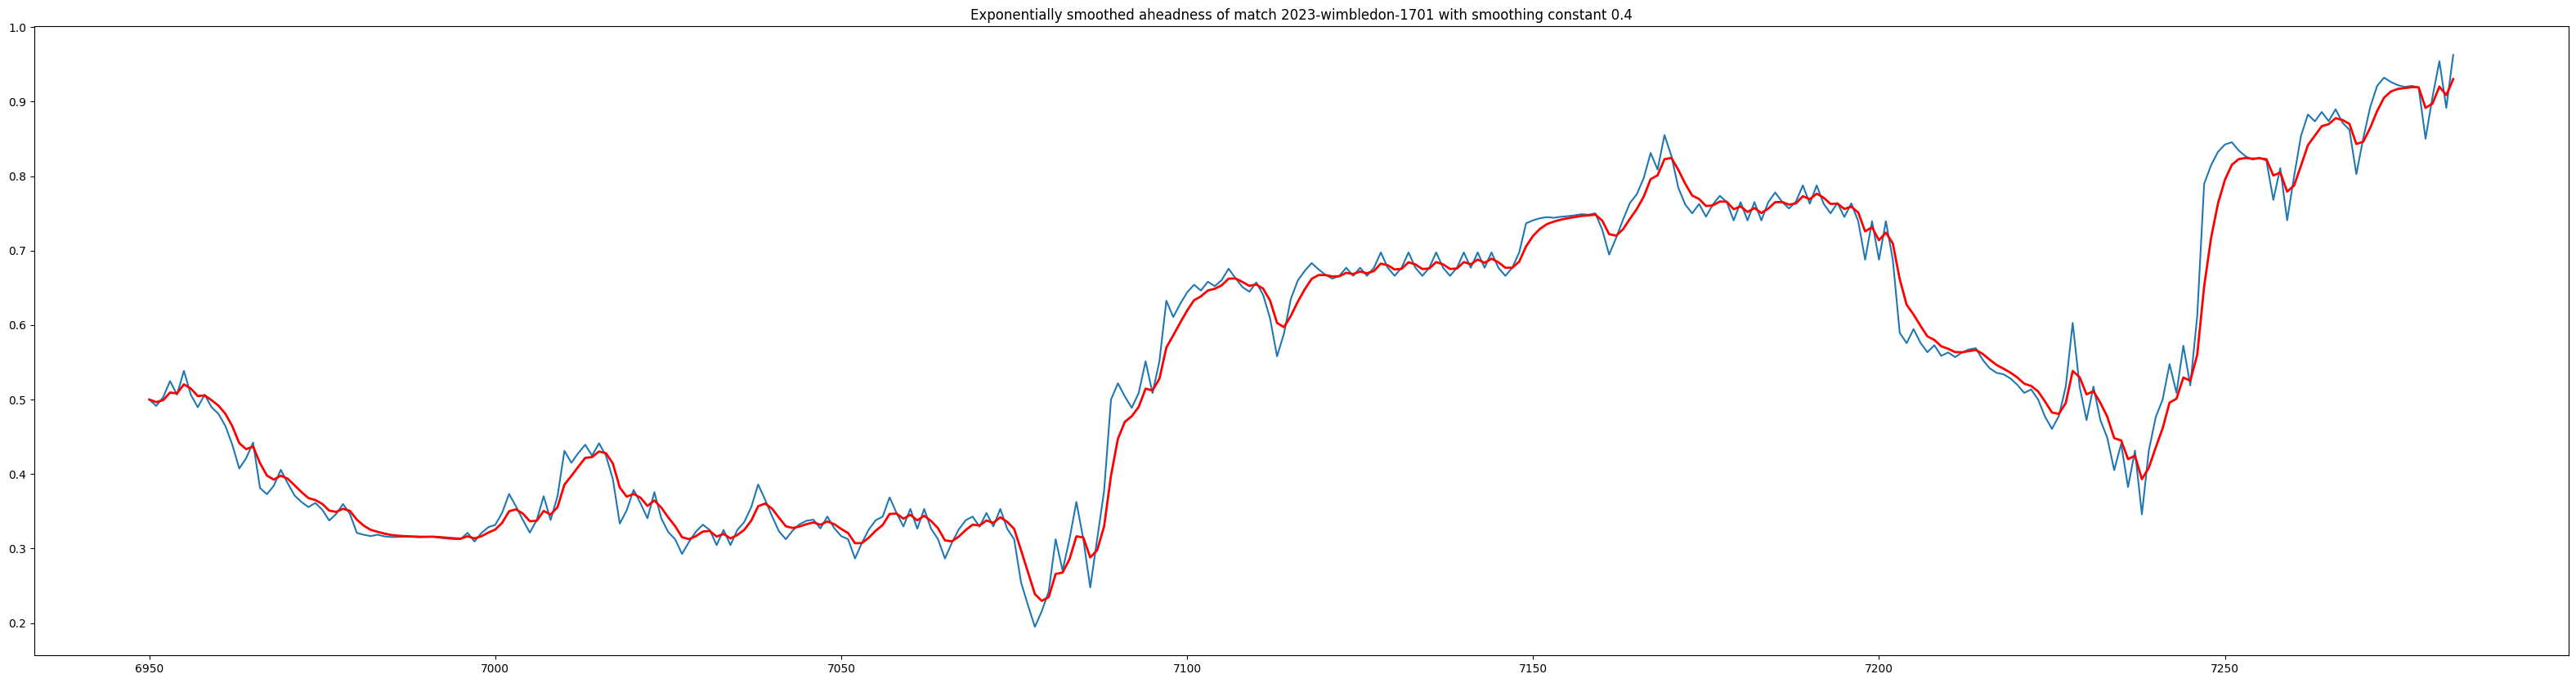

In [12]:
test_match_id = '2023-wimbledon-1701'
test_match = df[df['match_id'] == test_match_id]
alpha = 0.4 # smoothing factor
df['simple_exp_smoothed_aheadness'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'simple_exp_smoothed_aheadness'] = df.loc[i, "aheadness"]
    else:
        df.loc[i, 'simple_exp_smoothed_aheadness'] = alpha*df.loc[i, 'aheadness'] + (1 - alpha) * df.loc[i-1, 'simple_exp_smoothed_aheadness']

df['exp_error'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'exp_error'] = 0
    else:
        df.loc[i, 'exp_error'] = df.loc[i, 'aheadness'] - df.loc[i, 'simple_exp_smoothed_aheadness']


plt.figure(figsize=(40,10))
plt.plot(df[df['match_id'] == test_match_id]['aheadness'])
plt.plot(df[df['match_id'] == test_match_id]['simple_exp_smoothed_aheadness'], 'r', lw=2)
plt.title("Exponentially smoothed aheadness of match " + str(test_match_id) + " with smoothing constant " + str(alpha))
plt.show()

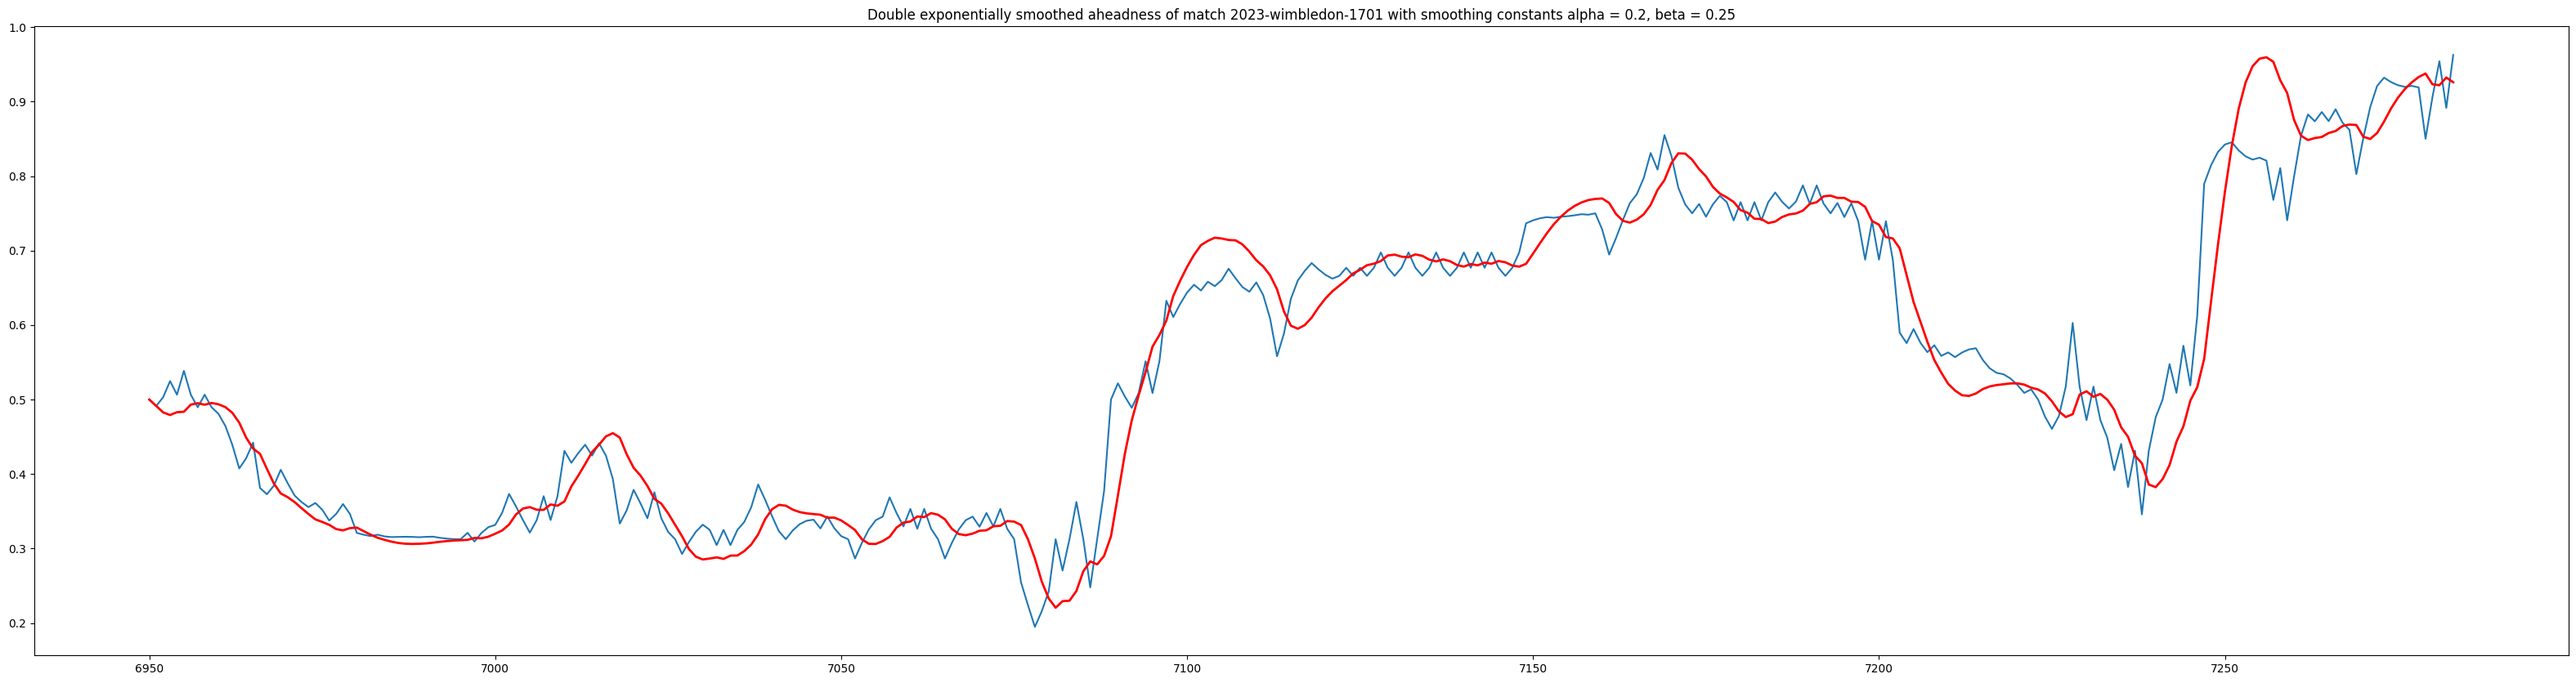

In [16]:
alpha = 0.2 # data smoothing factor 
beta = 0.25 # trend smoothing factor
df['double_exp_smoothed_aheadness'] = 0.0
s_t = [0.0]*len(df)
b_t = [0.0]*len(df)
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        s_t[i] = df.loc[i, "aheadness"]
        b_t[i] = df.loc[i + 1, "aheadness"] - df.loc[i, "aheadness"]
        df.loc[i, 'double_exp_smoothed_aheadness'] = df.loc[i, "aheadness"]
    else:
        s_t[i] = alpha * df.loc[i, "aheadness"] + (1 - alpha) * (s_t[i-1] + b_t[i-1])
        b_t[i] = beta * (s_t[i] - s_t[i-1]) + (1 - beta) * b_t[i-1]
        df.loc[i, 'double_exp_smoothed_aheadness'] = s_t[i-1] + b_t[i-1]

plt.figure(figsize=(40,10))
plt.plot(df[df['match_id'] == test_match_id]['aheadness'])
plt.plot(df[df['match_id'] == test_match_id]['double_exp_smoothed_aheadness'], 'r', lw=2)
plt.title("Double exponentially smoothed aheadness of match " + str(test_match_id) + " with smoothing constants alpha = " + str(alpha) + ", beta = " + str(beta))
plt.show()

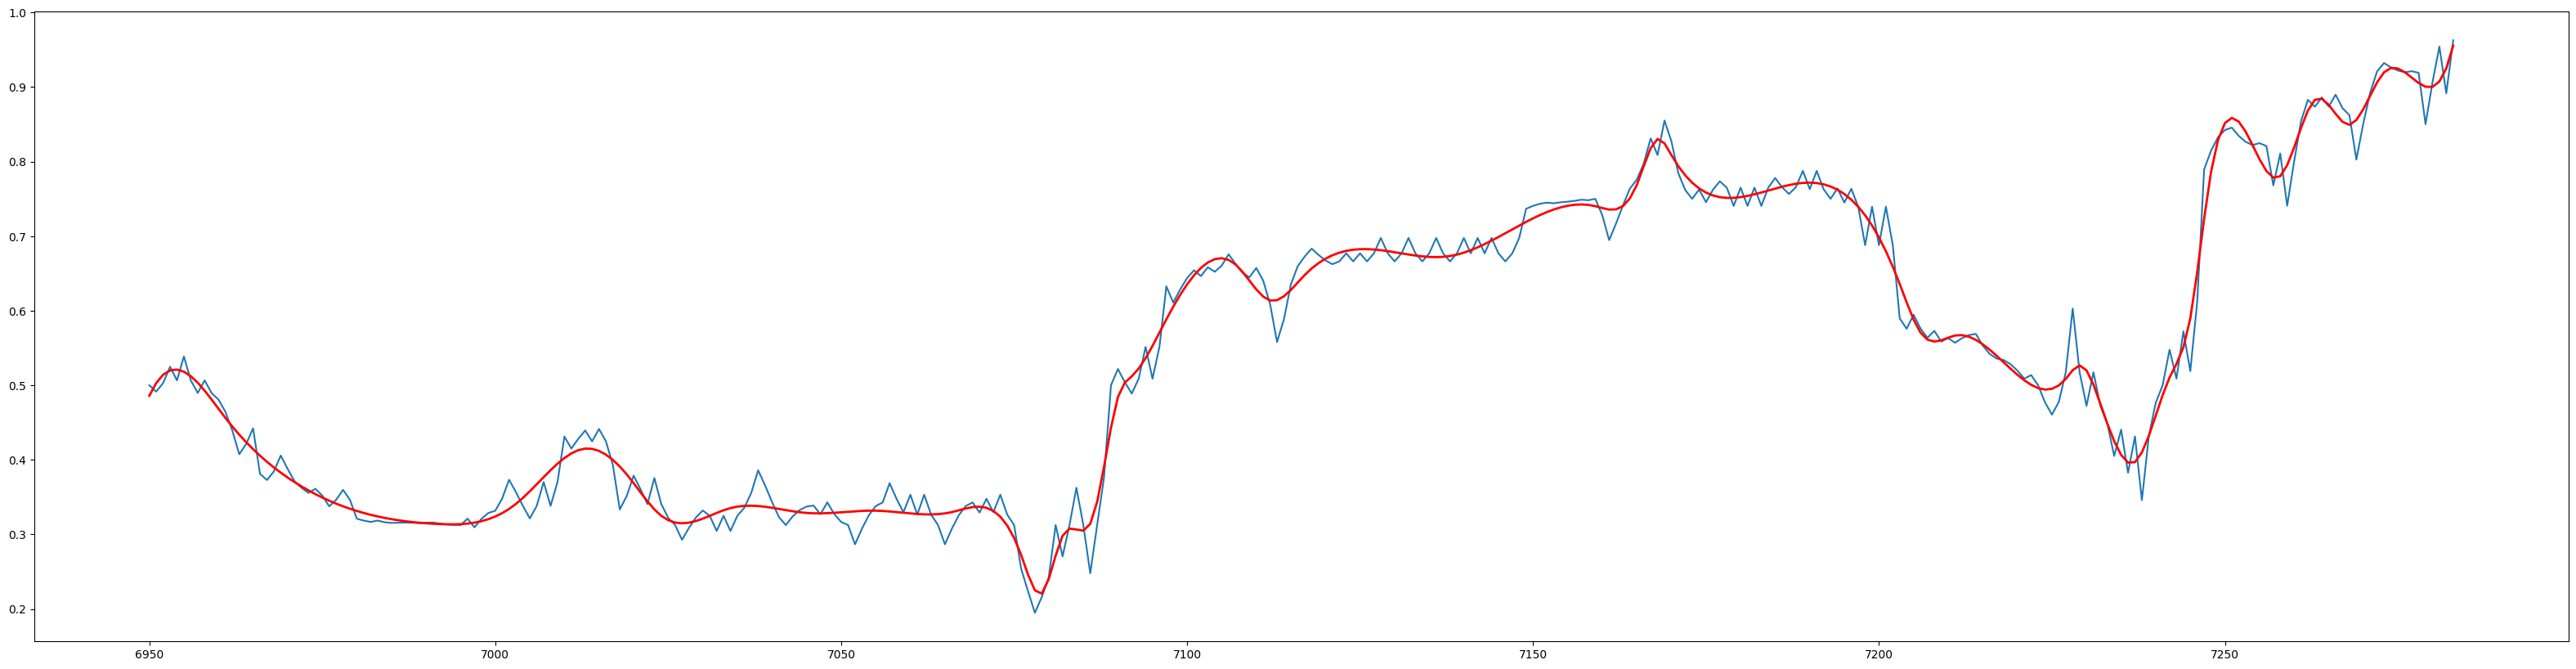

In [17]:
# FUTURE
ans = []
for name, group in df.groupby(['match_id']):
    y = group['aheadness']
    x = range(len(y))
    spl = UnivariateSpline(x, y)
    spl.set_smoothing_factor(0.15)
    #print(list(spl(x)))
    ans = np.append(ans, list(spl(x)))
#print(ans)
df["smooth_ahead"] = ans

df['past_aided_aheadness'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1 or df.loc[i, 'point_no'] == 2:
        df.loc[i, 'past_aided_aheadness'] = df.loc[i, 'aheadness']
    else:
        df.loc[i, 'past_aided_aheadness'] = (df.loc[i, 'aheadness'] + df.loc[i-1, 'aheadness'] + df.loc[i-2, 'aheadness'])/3.0


plt.figure(figsize=(40,10))
plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['aheadness'])
plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['smooth_ahead'], 'r', lw=2)

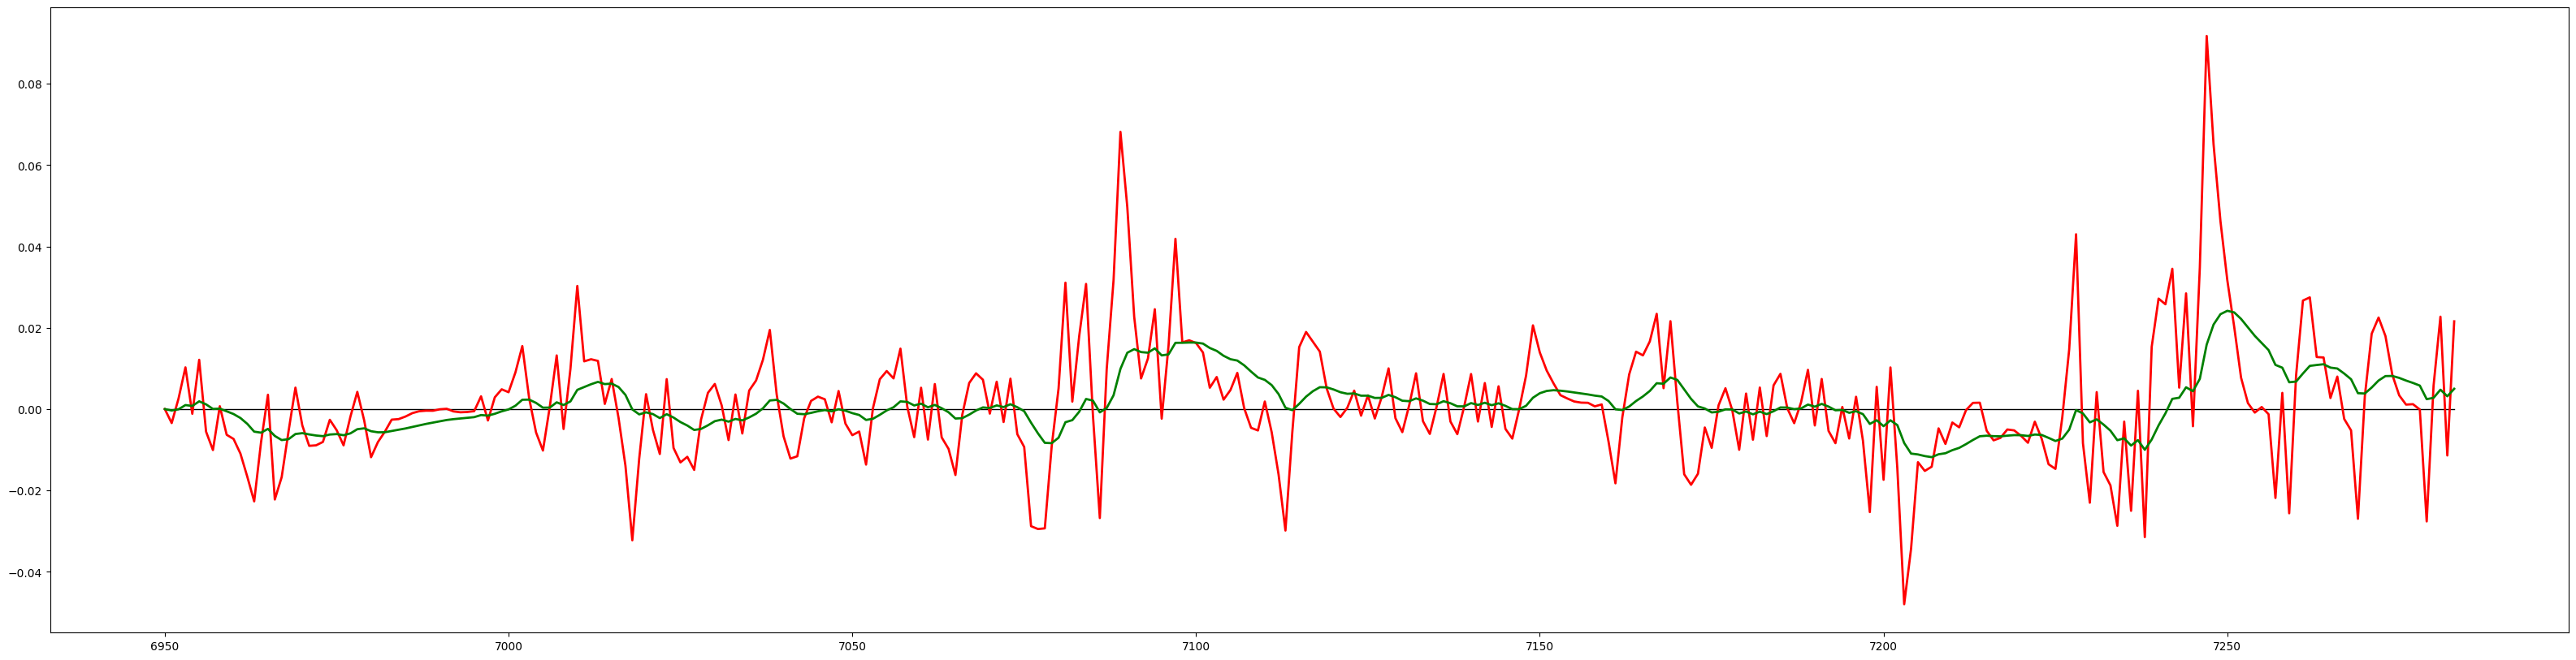

In [19]:
df['smooth_aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'smooth_aheadness_dev'] = 0
    else:
        df.loc[i, 'smooth_aheadness_dev'] = df.loc[i, 'smooth_ahead'] - df.loc[i-1, 'smooth_ahead']


df['aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'aheadness_dev'] = 0
    else:
        df.loc[i, 'aheadness_dev'] = df.loc[i, 'aheadness'] - df.loc[i-1, 'aheadness']

df['simple_exp_smoothed_aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'simple_exp_smoothed_aheadness_dev'] = 0
    else:
        df.loc[i, 'simple_exp_smoothed_aheadness_dev'] = df.loc[i, 'simple_exp_smoothed_aheadness'] - df.loc[i-1, 'simple_exp_smoothed_aheadness']

test_match = df[df['match_id'] == test_match_id]
plt.figure(figsize=(40,10))
plt.plot(np.floor(test_match['p2_break_pt_missed']/2 + 0.01), 'black', lw=1,)
#plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['aheadness_dev'], 'g', lw=2)
plt.plot(test_match['simple_exp_smoothed_aheadness_dev'], 'r', lw=2)

alpha = 0.1
df['exp_smoothed_simple_exp_smoothed_aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'exp_smoothed_simple_exp_smoothed_aheadness_dev'] = df.loc[i, "simple_exp_smoothed_aheadness_dev"]
    else:
        df.loc[i, 'exp_smoothed_simple_exp_smoothed_aheadness_dev'] = alpha*df.loc[i, 'simple_exp_smoothed_aheadness_dev'] + (1 - alpha) * df.loc[i-1, 'exp_smoothed_simple_exp_smoothed_aheadness_dev']
test_match = df[df['match_id'] == test_match_id]
plt.plot(test_match['exp_smoothed_simple_exp_smoothed_aheadness_dev'], 'g', lw=2)

In [30]:
future_points_to_analyze = 4
mom = []
points_scored = []
expectations = []
delta = []
df["exp_delta"]  = 0.0
deriv_type = "exp_smoothed_simple_exp_smoothed_aheadness_dev"
for i in range(len(df)):
    momentum = df.loc[i, deriv_type]
    serving = df.loc[i, "server"]
    if momentum > 0:
        points_won = 0
        expectation = 0
        full_analysis = True
        for j in range(future_points_to_analyze):
            point = i + j
            if point >= len(df) - 1 or df.loc[point, "point_no"] == 1:
                full_analysis = False
                break
            if df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 1:
                points_won += 1
                expectation += p
            elif df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 2:
                points_won += 1
                expectation += 1 - p
            elif df.loc[point, "point_victor"] == 2 and df.loc[point, "server"] == 1:
                expectation += p
            else:
                expectation += 1 - p
        if full_analysis:
            mom.append(abs(momentum))
            points_scored.append(points_won)
            expectations.append(expectation)
            delta.append(points_won - expectation)
            df.loc[i, "exp_delta"] = points_won - expectation
        else:
            df.loc[i, "exp_delta"] = 0
    
    if momentum < 0:
        points_won = 0
        expectation = 0
        full_analysis = True
        for j in range(future_points_to_analyze):
            point = i + j
            if point >= len(df) - 1 or df.loc[point, "point_no"] == 1:
                full_analysis = False
                break
            if df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 1:
                expectation += 1 - p
            elif df.loc[point, "point_victor"] == 1 and df.loc[point, "server"] == 2:
                expectation += p
            elif df.loc[point, "point_victor"] == 2 and df.loc[point, "server"] == 1:
                points_won += 1
                expectation += 1 - p
            else:
                points_won += 1
                expectation += p
        if full_analysis:
            mom.append(abs(momentum))
            points_scored.append(points_won)
            expectations.append(expectation)
            delta.append(points_won - expectation)
            df.loc[i, "exp_delta"] = points_won - expectation
        else:
            df.loc[i, "exp_delta"] = 0

Text(0.5, 1.0, '2023-wimbledon-1701: Analyzing 4 points ahead, outperforming expectations by 1')

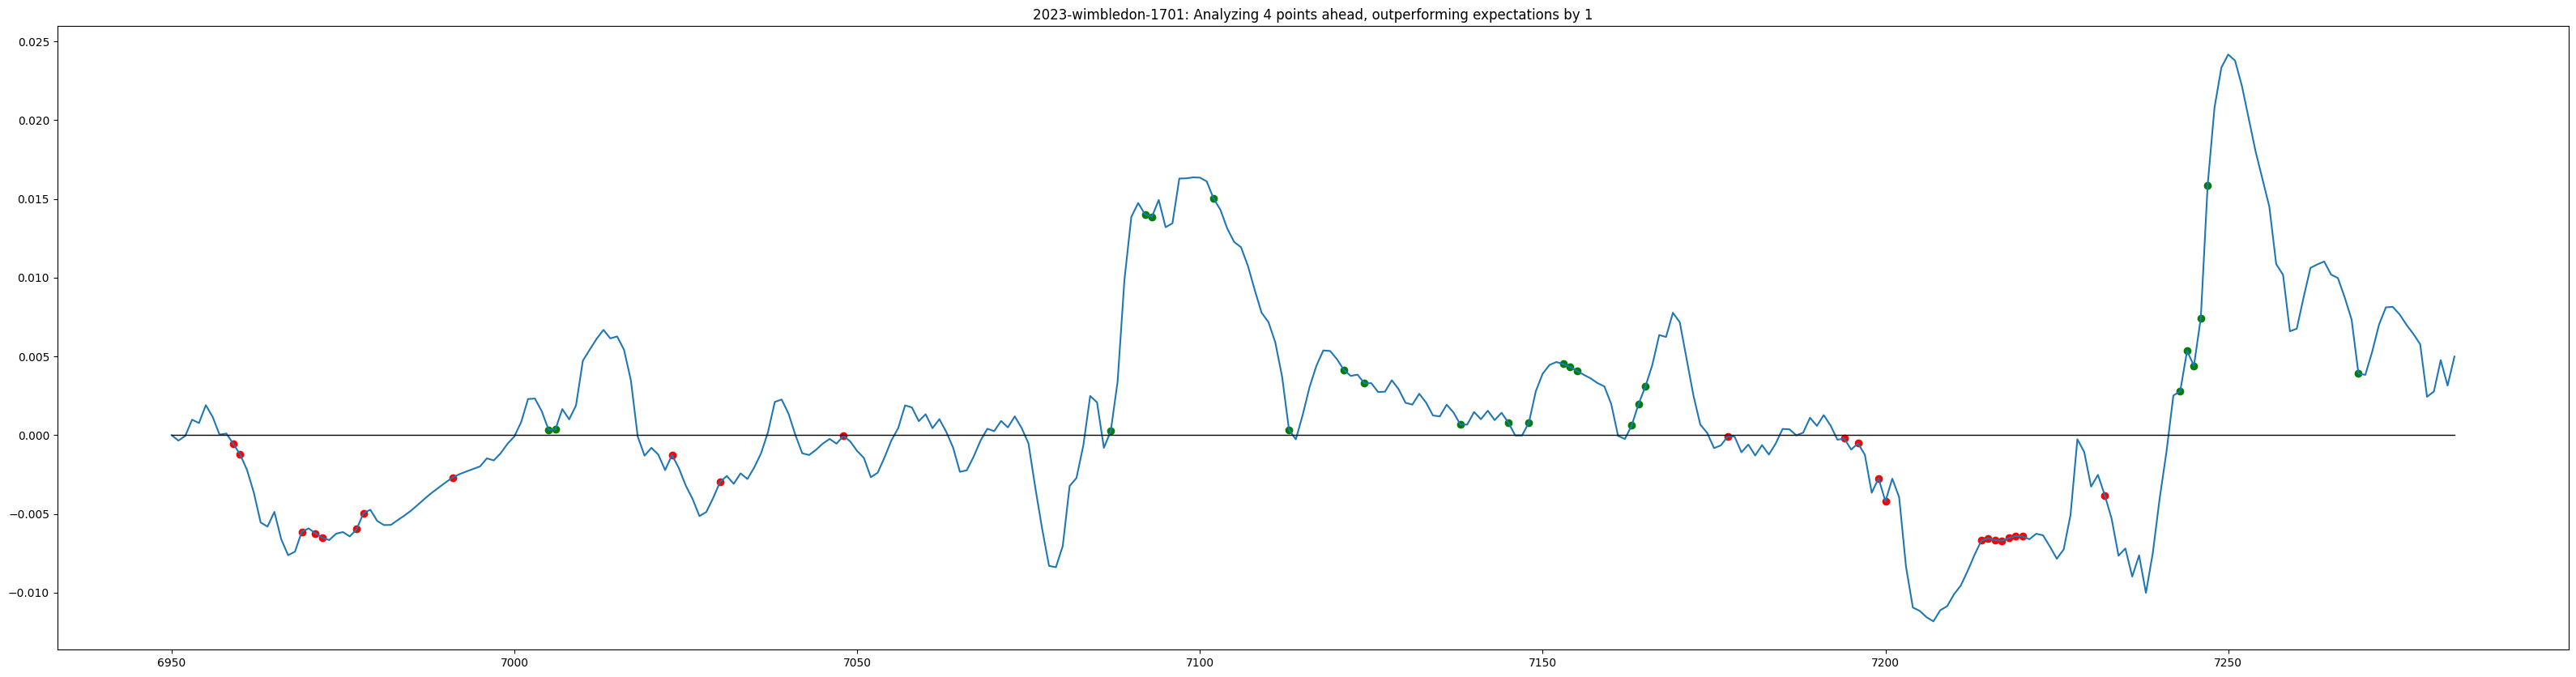

In [36]:
test_match = df[df['match_id'] == test_match_id]
plt.figure(figsize=(40,10))
p1_indices = []
big_p1_delta = []
p2_indices = []
big_p2_delta = []
first_element = 0
for i in range(len(df)):
    if df.loc[i, "match_id"] == test_match_id and df.loc[i, "point_no"] == 1:
        first_element = i
        break
outperform_val = 1
for i in range(first_element, first_element + len(test_match)):
    if test_match.loc[i, "exp_delta"] > outperform_val and test_match.loc[i, deriv_type] > 0:
        p1_indices.append(i)
        big_p1_delta.append(test_match.loc[i, deriv_type])
    if test_match.loc[i, "exp_delta"] > outperform_val and test_match.loc[i, deriv_type] < 0:
        p2_indices.append(i)
        big_p2_delta.append(test_match.loc[i, deriv_type])

plt.scatter(p1_indices, big_p1_delta, c = 'green')
plt.scatter(p2_indices, big_p2_delta, c = 'red')
plt.plot(test_match[deriv_type])
plt.plot(np.floor(test_match['p2_break_pt_missed']/2 + 0.01), 'black', lw=1,)
plt.title(test_match_id + ": Analyzing " + str(future_points_to_analyze) + " points ahead, outperforming expectations by " + str(outperform_val))